Installing libraries (if necessary)

In [1]:
#%pip install nltk scikit-learn
import nltk
import os
import json
import math
import re
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from nltk.collocations import TrigramCollocationFinder
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/ferran/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/ferran/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Trigram division of the training and test data. Adding them to a `.json` file.

In [2]:
def generate_trigrams_json(input_json_path, output_json_path, min_freq=2):
    """
    Llegeix un JSON amb el corpus (idioma: text), calcula els trigrames
    i guarda un nou JSON amb el format (idioma: {trigrama: freqüència}).
    """
    if not os.path.exists(input_json_path):
        print(f"No s'ha trobat l'arxiu: {input_json_path}")
        return

    # 1. Carregar l'arxiu JSON
    with open(input_json_path, 'r', encoding='utf-8') as f:
        corpus = json.load(f)

    trigrams_data = {}

    # 2. Processar cada idioma
    print(f"\n=== Processant trigrames per a '{input_json_path}' ===")
    for lang, text in corpus.items():
        print(f"  Calculant {lang}...")
        
        # En passar-li un string, from_words itera lletra per lletra (n-grames de caràcters)
        finder = TrigramCollocationFinder.from_words(text)
        
        # 3. Aplicar el filtre de freqüència que has indicat
        if min_freq > 1:
            finder.apply_freq_filter(min_freq)
        
        # 4. Convertir els resultats al format 'trigrama': n_ocurrències
        lang_trigrams = {}
        for ngram_tuple, count in finder.ngram_fd.items():
            # Juntem la tupla ('t', 'h', 'e') per fer l'string "the"
            trigram_str = "".join(ngram_tuple)
            lang_trigrams[trigram_str] = count
            
        trigrams_data[lang] = lang_trigrams

    # 5. Guardar el resultat en un nou JSON
    with open(output_json_path, 'w', encoding='utf-8') as f:
        json.dump(trigrams_data, f, ensure_ascii=False)

    print(f"-> Guardat correctament a: {output_json_path}")


# Executem la funció per als dos arxius (train i test)
# Pots modificar min_freq=2 si vols un filtre diferent (o posar 1 per no filtrar-ne cap)
generate_trigrams_json('./corpus_train.json', './trigrams_train.json', min_freq=5)



=== Processant trigrames per a './corpus_train.json' ===
  Calculant deu...
  Calculant eng...
  Calculant fra...
  Calculant ita...
  Calculant nld...
  Calculant spa...
-> Guardat correctament a: ./trigrams_train.json


## 1. Lidstone Smoothing, following this formula:

$$
P^T(e_j) = P^T_{LID}(e_j)= \frac{C_t(e_j) + \lambda}{N_t + \lambda B}
$$

- $e_j$: Trigram to determine (or sentence)
- $B$: Number of different trigrams in the train corpus
- $N_t$: Number of trigrams in the train corpus
- $C_t(e_j)$: Number of occurencies of $e_j$ in the train corpus.

We fit the model with the training data, returning a `.json` file with the parameters $B$ and $N_t$, and a the list of trigrams with their counts i the train corpus, for each language.

The inference is made by maximizing the likelihood of the test document given the language model:

$$
\arg\max_{L} P(\hat{d} \mid L)
$$

Which is estimated using Maximum Likelihood Estimation (MLE) (assuming independence)

$$
P(\hat{d}) = P(e_1, \dots, e_s) = \prod_{j=1}^{s} P(e_j)
$$

Equivalenty;

$$
\log P(\hat{d}) = \sum_{j=1}^{s} \log P(e_j)
$$

Instead of multiplying probabilities in a massive loop, the code adds logarithms:
```python
log_prob_total += text_occurrences * math.log(prob_seen)
```

In [17]:
class LidstoneLanguageModel:
    def __init__(self, lambda_val=0.5):
        """
        Inicialitza el model amb un valor de lambda (λ).
        """
        self.lambda_val = lambda_val
        self.model_params = {}

    def fit(self, train_trigrams_json, output_model_json):
        """
        Llegeix el JSON de trigrames d'entrenament, calcula N_t i B per a cada idioma,
        i guarda els paràmetres i el corpus en un nou arxiu JSON.
        """
        if not os.path.exists(train_trigrams_json):
            raise FileNotFoundError(f"No s'ha trobat: {train_trigrams_json}")

        with open(train_trigrams_json, 'r', encoding='utf-8') as f:
            trigrams_data = json.load(f)

        for lang, trigrams_dict in trigrams_data.items():
            # N_t = Nombre total de trigrames en el corpus d'aquest idioma
            N_t = sum(trigrams_dict.values())
            
            # B = Nombre de trigrames diferents (mida del vocabulari d'aquest idioma)
            B = len(trigrams_dict.keys())
            
            self.model_params[lang] = {
                "lambda": self.lambda_val,
                "N_t": N_t,
                "B": B,
                "counts": trigrams_dict
            }

        # Guardem els paràmetres en un nou JSON
        with open(output_model_json, 'w', encoding='utf-8') as f:
            json.dump(self.model_params, f, ensure_ascii=False, indent=2)
            
        print(f"Model entrenat i paràmetres guardats a: {output_model_json}")

    def load_model(self, model_json):
        """
        Carrega els paràmetres d'un model prèviament entrenat.
        """
        if not os.path.exists(model_json):
            raise FileNotFoundError(f"No s'ha trobat el model a: {model_json}")
            
        with open(model_json, 'r', encoding='utf-8') as f:
            self.model_params = json.load(f)
        print(f"Model carregat correctament des de: {model_json}")

    def predict_text(self, text):
        """
        Donat un text pla preprocessat (sense dividir en trigrames),
        calcula la probabilitat per cada idioma i retorna el més probable.
        """
        if not self.model_params:
            raise ValueError("El model no està carregat. Fes .fit() o .load_model() abans.")

        # 1. Extreure els trigrames del text a predir (test)
        finder = TrigramCollocationFinder.from_words(text)
        test_trigrams = {"".join(k): v for k, v in finder.ngram_fd.items()}

        scores = {}

        # 2. Calcular la probabilitat per a cada idioma, seguint MLE.
        for lang, params in self.model_params.items():
            L = params["lambda"]
            N_t = params["N_t"]
            B = params["B"]
            counts = params["counts"]

            # Denominador de la fórmula de Lidstone: (N_t + λ * B)
            denominator = N_t + (L * B)
            
            # Probabilitat per a un trigrama no vist al corpus d'entrenament (C_t = 0)
            prob_unseen = L / denominator if denominator > 0 else 1e-10
            log_prob_unseen = math.log(prob_unseen) if prob_unseen > 0 else float('-inf')

            log_prob_total = 0.0

            # Apliquem la fórmula a cada trigrama del text
            for trigram, text_occurrences in test_trigrams.items():
                C_t = counts.get(trigram, 0)
                
                if C_t > 0:
                    # Si el trigrama existeix al corpus d'entrenament
                    prob_seen = (C_t + L) / denominator
                    log_prob_total += text_occurrences * math.log(prob_seen)
                else:
                    # Si és un trigrama desconegut (Out Of Vocabulary)
                    log_prob_total += text_occurrences * log_prob_unseen

            scores[lang] = log_prob_total
            
        # 3. Escollir l'idioma amb el logaritme de probabilitat més alt (el menys negatiu)
        best_lang = max(scores, key=scores.get)
        return best_lang, scores
    
    def refining_lambda(self, model_json, k_folds=4):
        """
        Refina el valor de lambda per a cada idioma utilitzant validació creuada sobre les dades de train.
        Maximitza l'Accuracy (percentatge d'encerts) simulant la predicció contra la resta d'idiomes.
        Desa el nou fitxer amb les lambdes modificades sobreescrivint l'original.
        """
        if not self.model_params:
            self.load_model(model_json)
            
        lambdas_to_test = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1.0]
        
        for lang, params in self.model_params.items():
            print(f"Refinant lambda per a: {lang}...")
            counts = params["counts"]
            
            # Converteix el diccionari de freqüències en una llista d'elements
            # Expandim els trigrames segons les vegades que apareixen
            trigrams_list = []
            for trigram, count in counts.items():
                trigrams_list.extend([trigram] * count)
                
            # Si hi ha pocs trigrames, evitem error
            if len(trigrams_list) < k_folds:
                print(f"  Pocs trigrames per {lang}, es manté la lambda actual.")
                continue
                
            # Modelem una proporció d'split equivalent al 75-25 remenant les dades
            random.shuffle(trigrams_list)
            fold_size = len(trigrams_list) // k_folds
            
            best_lambda = params["lambda"]
            best_accuracy = -1.0  # L'accuracy va de 0 a 1, inicialitzem en negatiu
            
            # Evaluar cadascuna de les lambdes
            for l_candidate in lambdas_to_test:
                avg_accuracy = 0.0
                
                # Apliquem Cross-Validation manual (ex: 4 folds = 75% train / 25% test rotatiu)
                for i in range(k_folds):
                    # Definició de Train i Validation Split 
                    val_start = i * fold_size
                    val_end = (i + 1) * fold_size if i != k_folds - 1 else len(trigrams_list)
                    
                    val_set = trigrams_list[val_start:val_end]
                    train_set = trigrams_list[:val_start] + trigrams_list[val_end:]
                    
                    # Generem estadístiques del train fold actual
                    train_counts = {}
                    for t in train_set:
                        train_counts[t] = train_counts.get(t, 0) + 1
                    
                    fold_Nt = len(train_set)
                    fold_B = len(train_counts)
                    fold_denominator = fold_Nt + (l_candidate * fold_B)
                    fold_unseen_prob = l_candidate / fold_denominator if fold_denominator > 0 else 1e-10
                    fold_log_unseen = math.log(fold_unseen_prob) if fold_unseen_prob > 0 else float('-inf')
                    
                    correct_predictions = 0
                    
                    # Avaluem L'ACCURACY classificant cada trigrama de validació
                    for t_val in val_set:
                        # 1. Puntuació (Score) que atorga l'idioma actual (train_set)
                        ct = train_counts.get(t_val, 0)
                        if ct > 0:
                            prob_seen = (ct + l_candidate) / fold_denominator
                            score_current = math.log(prob_seen)
                        else:
                            score_current = fold_log_unseen
                            
                        # 2. Comprovar si l'idioma actual venç a la resta d'idiomes del model
                        is_best = True
                        for other_lang, other_params in self.model_params.items():
                            if other_lang == lang:
                                continue
                            
                            # Paràmetres globals dels altres idiomes (estàtics durant aquesta comparació)
                            oL = other_params["lambda"]
                            oNt = other_params["N_t"]
                            oB = other_params["B"]
                            o_counts = other_params["counts"]
                            
                            o_denom = oNt + (oL * oB)
                            o_prob_unseen = oL / o_denom if o_denom > 0 else 1e-10
                            o_log_unseen = math.log(o_prob_unseen) if o_prob_unseen > 0 else float('-inf')
                            
                            o_ct = o_counts.get(t_val, 0)
                            if o_ct > 0:
                                o_prob = (o_ct + oL) / o_denom
                                score_other = math.log(o_prob)
                            else:
                                score_other = o_log_unseen
                                
                            # Si un altre idioma puntua el trigrama millor, perdem l'encert
                            if score_other >= score_current:
                                is_best = False
                                break
                                
                        # Si cap idioma supera la puntuació del nostre, és un encert
                        if is_best:
                            correct_predictions += 1
                    
                    # Accuracy d'aquest fold: encerts / total de mostres al fold
                    fold_accuracy = correct_predictions / len(val_set)
                    avg_accuracy += fold_accuracy
                
                # Mitjana total de l'Accuracy de tots els k_folds
                avg_accuracy /= k_folds
                print(f"  Lambda {l_candidate}: Accuracy = {avg_accuracy * 100:.2f}%, Idioma: {lang}")
                
                # Ara volem l'accuracy MÉS ALTA possible (més a prop de 1.0)
                if avg_accuracy > best_accuracy:
                    best_accuracy = avg_accuracy
                    best_lambda = l_candidate
            
            print(f"  Millor lambda per a {lang}: {best_lambda} (Accuracy: {best_accuracy * 100:.2f}%)")
            
            # Actualitzem els paràmetres locals amb la nova lambda guanyadora
            self.model_params[lang]["lambda"] = best_lambda

        # Sobreescriu el fitxer JSON amb les lambdes recalibrades
        with open(model_json, 'w', encoding='utf-8') as f:
            json.dump(self.model_params, f, ensure_ascii=False, indent=2)
            
        print(f"Refinament completat. Les lambdes optimitzades s'han sobreescrit a: {model_json}")

    
    def evaluate_model(self, test_corpus_json):
        """
        Avalua el model amb un corpus de test, dividit per frases, i mostra la matriu de confusió i el classification report.
        Cada frase del test corpus ha de tenir d'estar separada per doble espai i el format del JSON ha de ser {idioma: "frase1  frase2  frase3 ..."}.
        """
        if not self.model_params:
            raise ValueError("El model no està carregat. Fes .fit() o .load_model() abans.")
        
        if not os.path.exists(test_corpus_json):
            raise FileNotFoundError(f"No s'ha trobat el corpus de test a: {test_corpus_json}")
        
        with open(test_corpus_json, 'r', encoding='utf-8') as f:
            test_corpus = json.load(f)
        
        y_true = []
        y_pred = []
        
        for lang, text in test_corpus.items():
            # Suposem que les frases estan separades per doble espai
            sentences = text.split("  ")
            accuracy_lang = 0
            for sentence in sentences:
                sentence = sentence.strip()
                if sentence:  # Evitem frases buides
                    pred_lang, _ = self.predict_text(sentence)
                    y_true.append(lang)
                    y_pred.append(pred_lang)
                    accuracy_lang += (pred_lang == lang)
                    if lang != pred_lang:
                        print(f"Frase mal classificada: '{sentence}' (True: {lang} -> Predicted: {pred_lang})")
            print(f"Idioma: {lang}, Frases processades: {len(sentences)}, Accuracy parcial: {accuracy_lang / len(sentences) * 100:.2f}%")
        
        
        return confusion_matrix(y_true, y_pred), classification_report(y_true, y_pred)

        

In [18]:
model = LidstoneLanguageModel(lambda_val=0.5)
model.fit('./trigrams_train.json', './lidstone_model.json')

Model entrenat i paràmetres guardats a: ./lidstone_model.json


In [19]:
model.load_model('./lidstone_model.json')

Model carregat correctament des de: ./lidstone_model.json


In [20]:
model.refining_lambda('./lidstone_model.json', k_folds=4)

Refinant lambda per a: deu...
  Lambda 0.001: Accuracy = 50.90%, Idioma: deu
  Lambda 0.01: Accuracy = 50.90%, Idioma: deu
  Lambda 0.05: Accuracy = 50.90%, Idioma: deu
  Lambda 0.1: Accuracy = 50.87%, Idioma: deu
  Lambda 0.3: Accuracy = 50.86%, Idioma: deu
  Lambda 0.5: Accuracy = 50.87%, Idioma: deu
  Lambda 0.7: Accuracy = 50.83%, Idioma: deu
  Lambda 1.0: Accuracy = 50.83%, Idioma: deu
  Millor lambda per a deu: 0.05 (Accuracy: 50.90%)
Refinant lambda per a: eng...
  Lambda 0.001: Accuracy = 44.12%, Idioma: eng
  Lambda 0.01: Accuracy = 44.12%, Idioma: eng
  Lambda 0.05: Accuracy = 44.12%, Idioma: eng
  Lambda 0.1: Accuracy = 44.13%, Idioma: eng
  Lambda 0.3: Accuracy = 44.11%, Idioma: eng
  Lambda 0.5: Accuracy = 44.13%, Idioma: eng
  Lambda 0.7: Accuracy = 44.14%, Idioma: eng
  Lambda 1.0: Accuracy = 44.15%, Idioma: eng
  Millor lambda per a eng: 1.0 (Accuracy: 44.15%)
Refinant lambda per a: fra...
  Lambda 0.001: Accuracy = 46.61%, Idioma: fra
  Lambda 0.01: Accuracy = 46.61%, 

In [22]:
matrix, report = model.evaluate_model('./corpus_test.json')

Frase mal classificada: 'er studierte an der rhode island school of design.' (True: deu -> Predicted: nld)
Frase mal classificada: 'lebt jon snow … so heiß sieht der "hey arnold!"' (True: deu -> Predicted: eng)
Frase mal classificada: 'er lebt heute im karmapa buddhist international institute (kibi) in new delhi (indien).' (True: deu -> Predicted: eng)
Frase mal classificada: 'mit channing tatum, amanda seyfried. the last song ( mit dir an meiner seite) mit miley cyrus, liam hemsworth.' (True: deu -> Predicted: eng)
Frase mal classificada: 'bénédicte de peretti bénédicte de peretti ist gründerin und managing partner bei bp communications consulting.' (True: deu -> Predicted: fra)
Frase mal classificada: 'onlangs was er een beachvolleybaltoernoei in baal, de heimat van nys.' (True: deu -> Predicted: nld)
Frase mal classificada: 'im android open source project (aosp) existiert bereits ein fix.' (True: deu -> Predicted: eng)
Frase mal classificada: 'assassin's creed iv (uplay-code) für , 

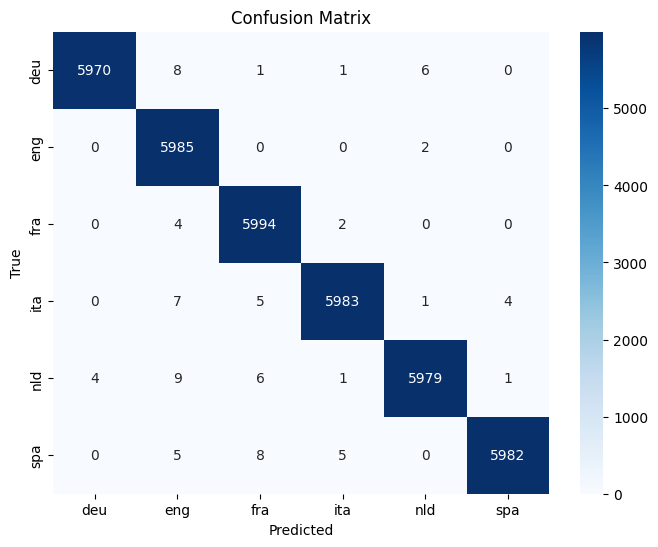

Classification Report:
               precision    recall  f1-score   support

         deu       1.00      1.00      1.00      5986
         eng       0.99      1.00      1.00      5987
         fra       1.00      1.00      1.00      6000
         ita       1.00      1.00      1.00      6000
         nld       1.00      1.00      1.00      6000
         spa       1.00      1.00      1.00      6000

    accuracy                           1.00     35973
   macro avg       1.00      1.00      1.00     35973
weighted avg       1.00      1.00      1.00     35973



In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.model_params.keys(), yticklabels=model.model_params.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()      
print("Classification Report:\n", report)

## 2. Interpolation smoothing


In [28]:
class InterpolationLanguageModel:
    """
    Model de detecció d'idioma basat en trigrames de caràcters amb
    Linear Interpolation Smoothing (Jelinek-Mercer).

    La probabilitat interpolada d'un trigrama "abc" és:

        P(c | ab) = λ₃ · P_MLE(abc)
                  + λ₂ · P_MLE(bc)
                  + λ₁ · P_MLE(c)
                  + λ₀ · P_uniform

    on λ₃ + λ₂ + λ₁ + λ₀ = 1  i  tots els λ ≥ 0.

    Els termes de backoff eviten probabilitats zero per a n-grames
    no vistos sense necessitat d'un paràmetre extern d'smoothing.

    Paràmetres
    ----------
    lambdas : tupla (λ₀, λ₁, λ₂, λ₃)
        Pesos per a la distribució uniforme, unigrames, bigrames i trigrames.
        Han de sumar 1. Per defecte (0.05, 0.10, 0.25, 0.60).
    """

    DEFAULT_LAMBDAS = (0.05, 0.10, 0.25, 0.60)

    def __init__(self, lambdas: tuple[float, float, float, float] | None = None):
        lambdas = lambdas or self.DEFAULT_LAMBDAS
        self._validate_lambdas(lambdas)
        self.lambdas = lambdas          # (λ₀, λ₁, λ₂, λ₃)
        self.model_params: dict = {}

    # ── Validació ────────────────────────────────────────────────────────────

    @staticmethod
    def _validate_lambdas(lambdas: tuple) -> None:
        if len(lambdas) != 4:
            raise ValueError("Cal passar exactament 4 lambdes: (λ₀, λ₁, λ₂, λ₃).")
        if any(l < 0 for l in lambdas):
            raise ValueError("Tots els lambdes han de ser ≥ 0.")
        if not math.isclose(sum(lambdas), 1.0, abs_tol=1e-6):
            raise ValueError(f"Els lambdes han de sumar 1. Suma actual: {sum(lambdas):.6f}")

    # ── Entrenament ──────────────────────────────────────────────────────────

    def fit(self, train_trigrams_json: str, output_model_json: str | None = None) -> None:
        """
        Entrena el model a partir d'un JSON de trigrames del corpus.

        El JSON ha de tenir el format:  { idioma: { trigrama: freqüència } }

        A més dels trigrames, calcula els comptadors de bigrames i unigrames
        necessaris per a la interpolació.
        """
        if not os.path.exists(train_trigrams_json):
            raise FileNotFoundError(f"No s'ha trobat: {train_trigrams_json}")

        with open(train_trigrams_json, "r", encoding="utf-8") as f:
            trigrams_data = json.load(f)

        for lang, trigram_counts in trigrams_data.items():
            # ── Trigrames ───────────────────────────────────────────────────
            N3 = sum(trigram_counts.values())

            # ── Bigrames: derivats dels trigrames (prefix de 2 caràcters) ──
            bigram_counts: dict[str, int] = {}
            for trigram, count in trigram_counts.items():
                bigram = trigram[:2]
                bigram_counts[bigram] = bigram_counts.get(bigram, 0) + count
            N2 = sum(bigram_counts.values())

            # ── Unigrames: derivats dels bigrames (primer caràcter) ─────────
            unigram_counts: dict[str, int] = {}
            for bigram, count in bigram_counts.items():
                unigram = bigram[0]
                unigram_counts[unigram] = unigram_counts.get(unigram, 0) + count
            N1 = sum(unigram_counts.values())

            # ── Mida de l'alfabet (per a la distribució uniforme) ───────────
            V = len(unigram_counts)

            self.model_params[lang] = {
                "lambdas": list(self.lambdas),
                "trigram_counts": trigram_counts,
                "bigram_counts": bigram_counts,
                "unigram_counts": unigram_counts,
                "N3": N3,
                "N2": N2,
                "N1": N1,
                "V": V,
            }

        if output_model_json:
            with open(output_model_json, "w", encoding="utf-8") as f:
                json.dump(self.model_params, f, ensure_ascii=False, indent=2)
            print(f"Model entrenat i guardat a: {output_model_json}")
        else:
            print("Model entrenat (no s'ha guardat en disc).")

    # ── Càrrega ───────────────────────────────────────────────────────────────

    def load_model(self, model_json: str) -> None:
        """Carrega els paràmetres d'un model prèviament entrenat."""
        if not os.path.exists(model_json):
            raise FileNotFoundError(f"No s'ha trobat el model a: {model_json}")

        with open(model_json, "r", encoding="utf-8") as f:
            self.model_params = json.load(f)
        print(f"Model carregat correctament des de: {model_json}")

    # ── Probabilitat interpolada ──────────────────────────────────────────────

    def _interpolated_log_prob(self, trigram: str, params: dict) -> float:
        """
        Calcula log P_interp(trigrama) per a un idioma concret.

        P_interp = λ₃·P(abc) + λ₂·P(bc) + λ₁·P(c) + λ₀·(1/V)
        """
        l0, l1, l2, l3 = params["lambdas"]
        N3 = params["N3"]
        N2 = params["N2"]
        N1 = params["N1"]
        V  = params["V"]

        trigram_counts  = params["trigram_counts"]
        bigram_counts   = params["bigram_counts"]
        unigram_counts  = params["unigram_counts"]

        # P_MLE de cadascun dels ordres
        p3 = trigram_counts.get(trigram, 0) / N3 if N3 > 0 else 0.0
        p2 = bigram_counts.get(trigram[1:], 0) / N2 if N2 > 0 else 0.0
        p1 = unigram_counts.get(trigram[2], 0) / N1 if N1 > 0 else 0.0
        p0 = 1.0 / V if V > 0 else 0.0          # distribució uniforme

        prob = l3 * p3 + l2 * p2 + l1 * p1 + l0 * p0

        # Amb λ₀ > 0, prob mai no serà 0 → log sempre definit
        return math.log(prob) if prob > 0 else float("-inf")

    # ── Predicció ─────────────────────────────────────────────────────────────

    def _score_text(self, test_trigrams: dict[str, int]) -> dict[str, float]:
        """Calcula el log-score interpolat per a cada idioma."""
        scores: dict[str, float] = {}
        for lang, params in self.model_params.items():
            log_prob_total = sum(
                freq * self._interpolated_log_prob(trigram, params)
                for trigram, freq in test_trigrams.items()
            )
            scores[lang] = log_prob_total
        return scores

    def predict_text(self, text: str) -> tuple[str, dict[str, float]]:
        """
        Donat un text pla preprocessat (sense dividir en trigrames),
        calcula la probabilitat interpolada per cada idioma i retorna el més probable.
        """
        if not self.model_params:
            raise ValueError("El model no està carregat. Fes .fit() o .load_model() primer.")

        # 1. Extreure els trigrames del text a predir (test)
        finder = TrigramCollocationFinder.from_words(text)
        test_trigrams = {"".join(k): v for k, v in finder.ngram_fd.items()}

        if not test_trigrams:
            raise ValueError("El text no conté trigrames vàlids.")

        scores = {}

        # 2. Calcular la probabilitat interpolada per a cada idioma
        for lang, params in self.model_params.items():
            log_prob_total = 0.0

            for trigram, text_occurrences in test_trigrams.items():
                log_prob = self._interpolated_log_prob(trigram, params)
                log_prob_total += text_occurrences * log_prob

            scores[lang] = log_prob_total

        # 3. Escollir l'idioma amb el log-score més alt
        best_lang = max(scores, key=scores.get)
        return best_lang, scores

    def evaluate(self, test_json: str) -> dict:
        """
        Avalua el model sobre un JSON de test (idioma → text),
        on cada frase està separada per doble espai.
        Mostra el classification report i la matriu de confusió.
        """
        if not os.path.exists(test_json):
            raise FileNotFoundError(f"No s'ha trobat: {test_json}")

        with open(test_json, "r", encoding="utf-8") as f:
            test_corpus = json.load(f)

        y_true = []
        y_pred = []
        labels = sorted(list(test_corpus.keys()))

        for true_lang, full_text in test_corpus.items():
            frases = [f.strip() for f in re.split(r' {2,}|\n+', full_text) if len(f.strip()) > 5]

            for frase in frases:
                pred = self.predict_text(frase)
                if pred is None:
                    continue
                predicted_lang, _ = pred
                y_true.append(true_lang)
                y_pred.append(predicted_lang)

        # Report
        print("Report de Classificació:")
        print(classification_report(y_true, y_pred, labels=labels))

        # Matriu de confusió
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(cmap="Blues", values_format="d")
        plt.title("Matriu de Confusió d'Identificació d'Idioma")
        plt.show()

        return cm

In [29]:
model2 = InterpolationLanguageModel()

In [30]:
model2.fit('./trigrams_train.json', './interpolation_model.json')

Model entrenat i guardat a: ./interpolation_model.json


In [36]:
model2.load_model('./interpolation_model.json')

Model carregat correctament des de: ./interpolation_model.json


Report de Classificació:
              precision    recall  f1-score   support

         deu       0.98      0.98      0.98      5986
         eng       0.94      0.99      0.97      5987
         fra       1.00      0.94      0.97      6000
         ita       0.97      0.98      0.98      6000
         nld       0.98      0.97      0.97      6000
         spa       0.98      0.99      0.98      6000

    accuracy                           0.98     35973
   macro avg       0.98      0.98      0.98     35973
weighted avg       0.98      0.98      0.98     35973



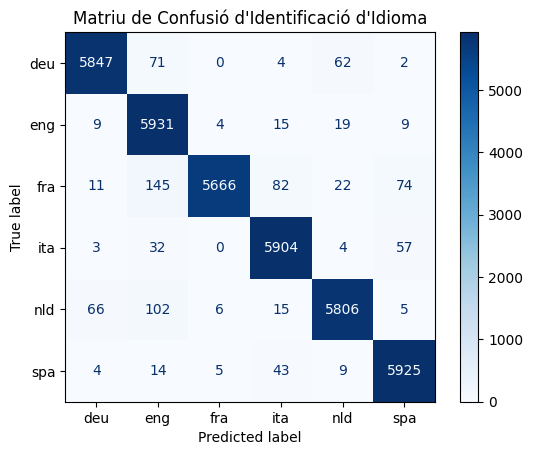

array([[5847,   71,    0,    4,   62,    2],
       [   9, 5931,    4,   15,   19,    9],
       [  11,  145, 5666,   82,   22,   74],
       [   3,   32,    0, 5904,    4,   57],
       [  66,  102,    6,   15, 5806,    5],
       [   4,   14,    5,   43,    9, 5925]])

In [37]:
model2.evaluate('./corpus_test.json')